# Price Analysis

This notebook loads  price data from the CSV files in `data/`, combines the available days, and starts by calculating rolling volatility from the mid-price series.

Change `DATA_GLOB` if you want to narrow the input files.


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

DATA_GLOB = "data/prices_round_*.csv"
PRODUCT = "INTARIAN_PEPPER_ROOT"
ROLLING_WINDOW = 80



In [ ]:
price_paths = sorted(Path().glob(DATA_GLOB))
raw_prices = pd.concat((pd.read_csv(path, sep=";") for path in price_paths), ignore_index=True)

prices = (
    raw_prices.loc[raw_prices["product"] == PRODUCT]
    .copy()
    .sort_values(["day", "timestamp"])
    .reset_index(drop=True)
)

# Recalculate mid_price as average of bid and ask when both available
prices["mid_price"] = prices.apply(
    lambda row: (row["bid_price_1"] + row["ask_price_1"]) / 2 
    if pd.notna(row["bid_price_1"]) and pd.notna(row["ask_price_1"]) 
    else np.nan, 
    axis=1
)

# Fill NaN mid_price with forward fill, then backward fill to avoid gaps in the series
prices["mid_price"] = prices["mid_price"].ffill().bfill()

prices["event_index"] = range(len(prices))
price_paths, prices[["day", "timestamp", "product", "bid_price_1", "ask_price_1", "mid_price"]].head()

## Rolling Volatility

A common choice is to compute volatility on returns rather than on raw prices. Here we use percentage returns of the `mid_price`, then take a rolling standard deviation over the last `ROLLING_WINDOW` observations.


In [ ]:
prices["mid_return"] = prices["mid_price"].pct_change()
prices[f"rolling_volatility_{ROLLING_WINDOW}"] = (
    prices["mid_return"].rolling(ROLLING_WINDOW).std() * (ROLLING_WINDOW ** 0.5)
)

prices[[
    "day",
    "timestamp",
    "mid_price",
    "mid_return",
    f"rolling_volatility_{ROLLING_WINDOW}",
]].tail(25)


In [ ]:
prices[f"rolling_volatility_{ROLLING_WINDOW}"].describe()


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].plot(prices["event_index"], prices["mid_price"], color="tab:blue", linewidth=1.5)
axes[0].set_title(f"{PRODUCT} Mid Price")
axes[0].set_ylabel("Mid Price")

axes[1].plot(
    prices["event_index"],
    prices[f"rolling_volatility_{ROLLING_WINDOW}"],
    color="tab:red",
    linewidth=1.5,
)
axes[1].set_title(f"{PRODUCT} Rolling Volatility ({ROLLING_WINDOW} observations)")
axes[1].set_xlabel("Observation Index")
axes[1].set_ylabel("Volatility")

plt.tight_layout()
plt.show()


## Trend Persistence From Log Returns

To test whether TOMATOES trends tick to tick, compute log returns within each day, take the sign of each return, and compare it to the previous tick's sign. If the same-sign percentage is materially above `50%`, that suggests short-horizon persistence. Below `50%` suggests the series is more choppy or mean-reverting than trending.


In [ ]:
prices["log_return"] = prices.groupby("day")["mid_price"].transform(lambda s: np.log(s).diff())
prices["log_return_sign"] = np.sign(prices["log_return"])
prices["prev_log_return_sign"] = prices.groupby("day")["log_return_sign"].shift(1)

same_sign_mask = (
    prices["log_return_sign"].notna()
    & prices["prev_log_return_sign"].notna()
    & prices["log_return_sign"].ne(0)
    & prices["prev_log_return_sign"].ne(0)
)

trend_summary = pd.DataFrame(
    {
        "same_sign_pct": [
            (prices.loc[same_sign_mask, "log_return_sign"] == prices.loc[same_sign_mask, "prev_log_return_sign"]).mean() * 100
        ],
        "opposite_sign_pct": [
            (prices.loc[same_sign_mask, "log_return_sign"] != prices.loc[same_sign_mask, "prev_log_return_sign"]).mean() * 100
        ],
        "zero_involved_pct": [
            ((prices["log_return_sign"].eq(0) | prices["prev_log_return_sign"].eq(0)).fillna(False)).mean() * 100
        ],
        "observations_used": [int(same_sign_mask.sum())],
    },
    index=["overall"],
).round(2)

trend_by_day = (
    prices.loc[same_sign_mask, ["day", "log_return_sign", "prev_log_return_sign"]]
    .assign(same_sign=lambda df: df["log_return_sign"] == df["prev_log_return_sign"])
    .groupby("day")["same_sign"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "same_sign_pct", "count": "observations_used"})
)
trend_by_day["same_sign_pct"] = (trend_by_day["same_sign_pct"] * 100).round(2)

print(
    "TOMATOES shows short-horizon trend persistence."
    if trend_summary.loc["overall", "same_sign_pct"] > 50
    else "TOMATOES does not show short-horizon trend persistence; sign flips are more common than same-direction moves."
)

trend_summary, trend_by_day


In [ ]:
trend_summary, trend_by_day
# Plot log returns
plt.figure(figsize=(14, 6))
plt.plot(prices["event_index"], prices["log_return"], color="tab:green", linewidth=1)
plt.title(f"{PRODUCT} Log Returns")
plt.xlabel("Observation Index")
plt.ylabel("Log Return")
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# Plot log returns
plt.figure(figsize=(14, 6))
plt.plot(prices["event_index"], prices["log_return"], color="tab:green", linewidth=1)
plt.title(f"{PRODUCT} Log Returns")
plt.xlabel("Observation Index")
plt.ylabel("Log Return")
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


In [ ]:
# Histogram of log returns
plt.figure(figsize=(10, 6))
plt.hist(prices["log_return"].dropna(), bins=50, color="tab:orange", edgecolor="black")
plt.title(f"{PRODUCT} Log Returns Histogram")
plt.xlabel("Log Return")
plt.ylabel("Frequency")
plt.show()


# Stats on log returns signs
log_returns_clean = prices["log_return"].dropna()
positive = (log_returns_clean > 0).sum()
negative = (log_returns_clean < 0).sum()
zero = (log_returns_clean == 0).sum()
total = len(log_returns_clean)

print(f"Log Returns Stats:")
print(f"Positive: {positive} ({positive/total*100:.2f}%)")
print(f"Negative: {negative} ({negative/total*100:.2f}%)")
print(f"Zero: {zero} ({zero/total*100:.2f}%)")
print(f"Total observations: {total}")

In [67]:
# Specific requested probabilities
print("\nSpecific Transitions:")
print(f"P(Positive after Negative): {transition_probs.loc[-1, 1]:.2f}%")
print(f"P(Negative after Positive): {transition_probs.loc[1, -1]:.2f}%")
print(f"P(Positive after Zero): {transition_probs.loc[0, 1]:.2f}%")
print(f"P(Zero after Zero): {transition_probs.loc[0, 0]:.2f}%")
print(f"P(Negative after Zero): {transition_probs.loc[0, -1]:.2f}%")
print(f"P(Negative after Negative): {transition_probs.loc[-1, -1]:.2f}%")
print(f"P(Positive after Positive): {transition_probs.loc[1, 1]:.2f}%")


Specific Transitions:
P(Positive after Negative): 57.43%
P(Negative after Positive): 39.59%
P(Positive after Zero): 30.80%
P(Zero after Zero): 51.46%
P(Negative after Zero): 17.74%
P(Negative after Negative): 8.93%
P(Positive after Positive): 19.54%


In [ ]:
# Specific expected values
print("\nSpecific Expected Returns:")
print(f"E[Return | Positive after Negative]: {expected_returns.loc[-1, 1]:.6f}")
print(f"E[Return | Negative after Positive]: {expected_returns.loc[1, -1]:.6f}")
print(f"E[Return | Positive after Zero]: {expected_returns.loc[0, 1]:.6f}")
print(f"E[Return | Zero after Zero]: {expected_returns.loc[0, 0]:.6f}")
print(f"E[Return | Negative after Zero]: {expected_returns.loc[0, -1]:.6f}")
print(f"E[Return | Negative after Negative]: {expected_returns.loc[-1, -1]:.6f}")
print(f"E[Return | Positive after Positive]: {expected_returns.loc[1, 1]:.6f}")


# Expected value from buying at first tick and holding entire series
total_log_return = prices["log_return"].sum()
total_return_pct = (np.exp(total_log_return) - 1) * 100
avg_log_return_per_tick = prices["log_return"].mean()
num_ticks = len(prices["log_return"].dropna())

print("Buy and Hold Strategy:")
print(f"Total log return: {total_log_return:.6f}")
print(f"Total return: {total_return_pct:.2f}%")
print(f"Average log return per tick: {avg_log_return_per_tick:.6f}")
print(f"Number of ticks: {num_ticks}")
print(f"Expected value per tick (average log return): {avg_log_return_per_tick:.6f}")

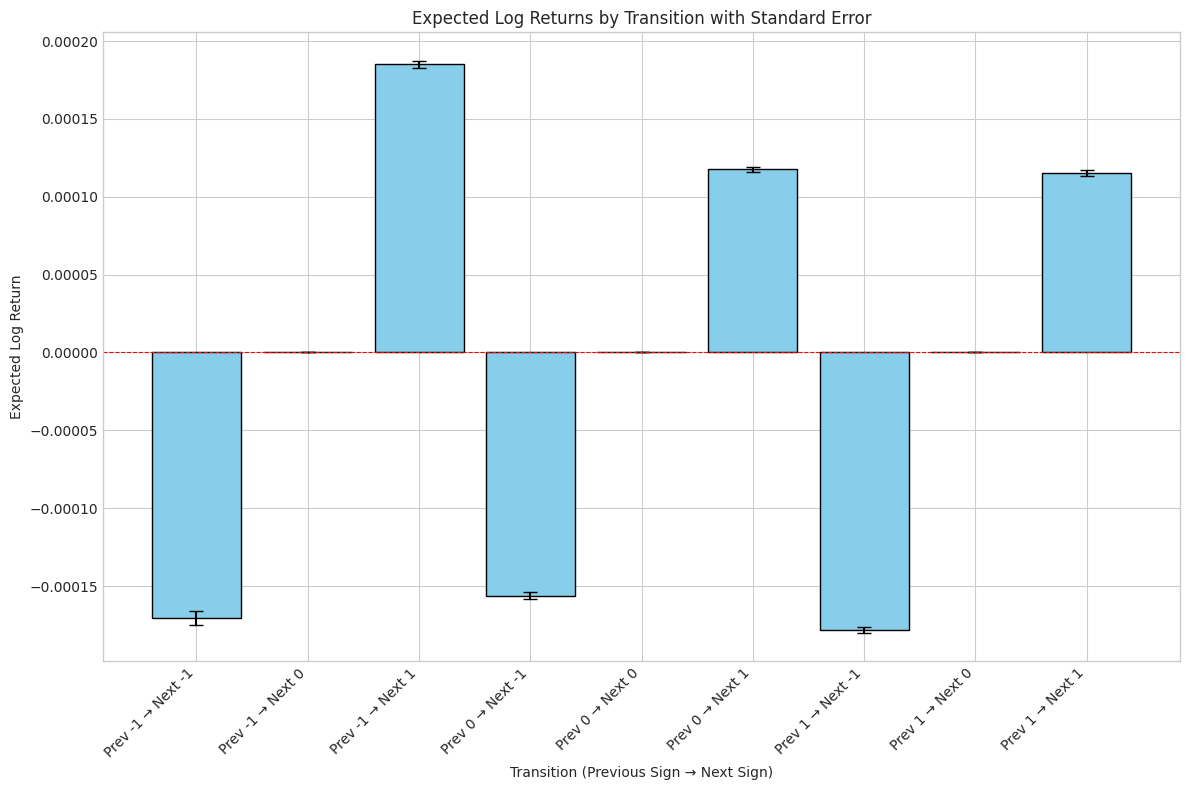

In [70]:
# Compute standard errors for each transition (std / sqrt(n))
se_returns = pd.DataFrame(index=[-1, 0, 1], columns=[-1, 0, 1])
counts = pd.DataFrame(index=[-1, 0, 1], columns=[-1, 0, 1])
for prev in [-1, 0, 1]:
    for next_ in [-1, 0, 1]:
        mask = (prices["prev_log_return_sign"] == prev) & (prices["log_return_sign"] == next_)
        count = mask.sum()
        counts.loc[prev, next_] = count
        if count > 0:
            std_val = prices.loc[mask, "log_return"].std()
            se_returns.loc[prev, next_] = std_val / np.sqrt(count)
        else:
            se_returns.loc[prev, next_] = 0

# Bar plot of expected returns with standard error bars
fig, ax = plt.subplots(figsize=(12, 8))
transitions = []
means = []
ses = []
for prev in [-1, 0, 1]:
    for next_ in [-1, 0, 1]:
        transitions.append(f"Prev {prev} → Next {next_}")
        means.append(expected_returns.loc[prev, next_])
        ses.append(se_returns.loc[prev, next_])

bars = ax.bar(transitions, means, yerr=ses, capsize=5, color='skyblue', edgecolor='black')
ax.set_title("Expected Log Returns by Transition with Standard Error")
ax.set_xlabel("Transition (Previous Sign → Next Sign)")
ax.set_ylabel("Expected Log Return")
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
print(f"Expected value per tick (average log return): {avg_log_return_per_tick:.6f}")

# Augmented Dickey-Fuller Test for Stationarity
from statsmodels.tsa.stattools import adfuller

# Test on log returns
result_returns = adfuller(prices["log_return"].dropna())
print("ADF Test on Log Returns:")
print(f"ADF Statistic: {result_returns[0]:.4f}")
print(f"p-value: {result_returns[1]:.4f}")
print("Critical Values:")
for key, value in result_returns[4].items():
    print(f"  {key}: {value:.4f}")
if result_returns[1] < 0.05:
    print("Conclusion: Log returns are stationary (reject null hypothesis of unit root).")
else:
    print("Conclusion: Log returns are non-stationary (fail to reject null hypothesis).")

# Test on prices (for comparison)
result_prices = adfuller(prices["mid_price"].dropna())
print("\nADF Test on Mid Prices:")
print(f"ADF Statistic: {result_prices[0]:.4f}")
print(f"p-value: {result_prices[1]:.4f}")
if result_prices[1] < 0.05:
    print("Conclusion: Prices are stationary.")
else:
    print("Conclusion: Prices are non-stationary (likely has a unit root).")


## Interpretation of Stationarity Tests

The ADF test results show that log returns are stationary (p-value ≈ 0.000), while mid prices are non-stationary. This combination is evidence of mean-reverting behavior with a long-term trend:

- **Stationary log returns**: The price changes are mean-reverting - deviations from the trend tend to correct themselves over time.
- **Non-stationary prices**: The price series has a unit root, indicating persistence and a long-term upward trend.
- **Implication**: The series exhibits mean reversion around a trending path, common in many financial assets where prices drift upward but fluctuate around that trend.

In [ ]:
# Strategy: Always buy after a negative log return (hold for one tick)
trade_mask = (
    prices["prev_log_return_sign"].eq(-1) & 
    prices["log_return"].notna()
)

expected_log_return_per_trade = prices.loc[trade_mask, "log_return"].mean()
num_trades = trade_mask.sum()
winning_trades = (prices.loc[trade_mask, "log_return"] > 0).sum()
win_rate = winning_trades / num_trades * 100 if num_trades > 0 else 0

expected_total_log_return = num_trades * expected_log_return_per_trade
expected_total_return_pct = (np.exp(expected_total_log_return) - 1) * 100

print("Strategy: Always Buy After Negative Log Return")
print(f"Number of trades: {num_trades}")
print(f"Winning trades: {winning_trades}")
print(f"Win rate: {win_rate:.2f}%")
print(f"Expected log return per trade: {expected_log_return_per_trade:.6f}")
print(f"Expected total log return: {expected_total_log_return:.6f}")
print(f"Expected total return: {expected_total_return_pct:.2f}%")

# Compare to buy-and-hold
print("\nComparison to Buy-and-Hold:")
print(f"Buy-and-Hold total return: {total_return_pct:.2f}%")
print(f"Strategy vs Buy-and-Hold: {expected_total_return_pct - total_return_pct:.2f} percentage points difference")

In [66]:
# Calculate Kelly Criterion for mean reversion strategy
positive_returns = prices.loc[trade_mask & (prices["log_return"] > 0), "log_return"]
negative_returns = prices.loc[trade_mask & (prices["log_return"] < 0), "log_return"]

avg_win = positive_returns.mean()
avg_loss = negative_returns.mean()  # negative value
win_prob = len(positive_returns) / num_trades
loss_prob = len(negative_returns) / num_trades

# Kelly fraction: f = (b*p - q)/b where b = avg_win / |avg_loss|
b = avg_win / abs(avg_loss)
kelly_fraction = (b * win_prob - loss_prob) / b

print("Kelly Criterion Calculation:")
print(f"Average win: {avg_win:.6f}")
print(f"Average loss: {abs(avg_loss):.6f}")
print(f"Win probability: {win_prob:.4f}")
print(f"Loss probability: {loss_prob:.4f}")
print(f"Odds ratio (b): {b:.4f}")
print(f"Kelly fraction: {kelly_fraction:.4f} ({kelly_fraction*100:.2f}% of capital per trade)")

Kelly Criterion Calculation:
Average win: 0.000185
Average loss: 0.000171
Win probability: 0.5743
Loss probability: 0.0893
Odds ratio (b): 1.0842
Kelly fraction: 0.4919 (49.19% of capital per trade)


## Capital Allocation and Trading Rules (Unlimited Capital, Limited Position Size)

With unlimited capital but limited position sizes (e.g., max 100 units per product in IMC Prosperity), allocation shifts from capital percentages to position utilization and strategy prioritization. The focus becomes maximizing position efficiency and managing inventory within limits.

### Mean Reversion Strategy
- **Signal**: Buy after a negative log return (prev_log_return_sign == -1)
- **Holding Period**: 1 tick
- **Win Rate**: 57.43%, Expected Return per Trade: 0.000091
- **Position Sizing**: 
  - Max position size (e.g., 100 units) = 100% utilization
  - Kelly suggests 49.19% of max position per trade → Use 25-50 units per trade
  - Since capital unlimited, you can run this on multiple uncorrelated assets simultaneously
- **Risk Management**: Stop loss at 2x average loss, max 5% position utilization drawdown
- **Allocation**: 40-50% of available position slots (prioritize high-edge assets)

### Market Making Strategy
- **Quoting Rules**: 
  - Bid = mid_price - spread/2, Ask = mid_price + spread/2
  - Spread = 0.5 × rolling_volatility_80 (or competitive level)
  - Quote at max position size (100 units per side) since capital unlimited
- **Inventory Management**: 
  - Target: 0 inventory
  - Adjust quotes aggressively to reduce position
  - If inventory > 20 units: Widen spread by 2x
  - If inventory < -20 units: Tighten spread by 0.5x
  - Max inventory: 50 units (50% of limit)
- **Allocation**: 50-60% of position slots (can run on all available products)
- **Risk**: Monitor inventory risk, not capital risk

### Overall Allocation
- **Position Slots**: Allocate to strategies based on edge strength
  - Mean Reversion: 40% (directional, high return potential)
  - Market Making: 60% (omnidirectional, steady profits)
- **Multi-Asset**: With unlimited capital, diversify across all available products
  - Run mean reversion on assets with strong mean-reverting signals
  - Run market making on all liquid products
- **Rebalancing**: Real-time based on inventory and signals

### General Rules
- **Position Limits**: Respect max position size (e.g., ±100 units)
- **Inventory Limits**: Never exceed 50% of max position to allow flexibility
- **Transaction Costs**: Critical with unlimited capital - minimize unnecessary trades
- **Backtesting**: Test with position limits, focus on inventory management
- **Opportunity Cost**: Since capital unlimited, prioritize strategies with highest expected return per position slot